In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [46]:
# Simulating normal behaviour logs (1000 rows, 20 features)
np.random.seed(42)
normal_data = np.random.normal(loc=0, scale=1, size=(1000, 20))

# Simulating anomalous behaviour (50 rows — extreme class imbalance)
anomaly_data = np.random.normal(loc=5, scale=1, size=(50, 20))

# Labels: 0 = normal, 1 = threat
X = np.vstack([normal_data, anomaly_data])
y = np.array([0]*1000 + [1]*50)

print(f"Total samples: {len(X)}")
print(f"Normal: {sum(y==0)}, Threats: {sum(y==1)}")

Total samples: 1050
Normal: 1000, Threats: 50


In [47]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train only on normal data — Autoencoder learns what "normal" looks like
X_normal = X_scaled[y == 0]
X_train, X_val = train_test_split(X_normal, test_size=0.1, random_state=42)

# Full test set includes both normal and anomalies
X_test = X_scaled
y_test = y

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

Training samples: 900
Validation samples: 100
Test samples: 1050


In [48]:
input_dim = X_train.shape[1]  # 20 features

inputs = Input(shape=(input_dim,))

# Encoder — compresses the data
encoded = Dense(64, activation='relu')(inputs)
encoded = Dense(32, activation='relu')(encoded)
bottleneck = Dense(16, activation='relu')(encoded)

# Decoder — reconstructs the data
decoded = Dense(32, activation='relu')(bottleneck)
decoded = Dense(64, activation='relu')(decoded)
outputs = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,908 (30.89 KB)

 Trainable params: 7,908 (30.89 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, X_val),
    shuffle=True,
    verbose=1
)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4752 - val_loss: 0.4552
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4333 - val_loss: 0.4168
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3942 - val_loss: 0.3690
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3551 - val_loss: 0.3364
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3181 - val_loss: 0.3079
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2905 - val_loss: 0.2852
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2692 - val_loss: 0.2712
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2523 - val_loss: 0.2484
Epoch 9/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2358 - val_loss: 0.2306
Epoch 10/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2164 - val_loss: 0.2176
Epoch 11/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2071 - val_loss: 0.2054
Epoch 12/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1974 - val_lo

In [50]:
X_pred = autoencoder.predict(X_test)
reconstruction_error = np.mean(np.power(X_test - X_pred, 2), axis=1)

print(f"Max reconstruction error: {reconstruction_error.max():.4f}")
print(f"Min reconstruction error: {reconstruction_error.min():.4f}")
print(f"Mean reconstruction error: {reconstruction_error.mean():.4f}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Max reconstruction error: 13.3955
Min reconstruction error: 0.0075
Mean reconstruction error: 0.5383


In [51]:
# Threshold = 95th percentile of training reconstruction error
train_pred = autoencoder.predict(X_train)
train_error = np.mean(np.power(X_train - train_pred, 2), axis=1)
threshold = np.percentile(train_error, 95)

print(f"Anomaly threshold: {threshold:.4f}")

y_pred = (reconstruction_error > threshold).astype(int)
print(f"Predicted threats: {sum(y_pred)}")
print(f"Actual threats: {sum(y_test)}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step
Anomaly threshold: 0.1981
Predicted threats: 102
Actual threats: 50


In [52]:
print(classification_report(y_test, y_pred, target_names=['Normal', 'Threat']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, reconstruction_error):.4f}")

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97      1000
      Threat       0.49      1.00      0.66        50

    accuracy                           0.95      1050
   macro avg       0.75      0.97      0.82      1050
weighted avg       0.98      0.95      0.96      1050

Confusion Matrix:
[[948  52]
 [  0  50]]
AUC-ROC: 1.0000


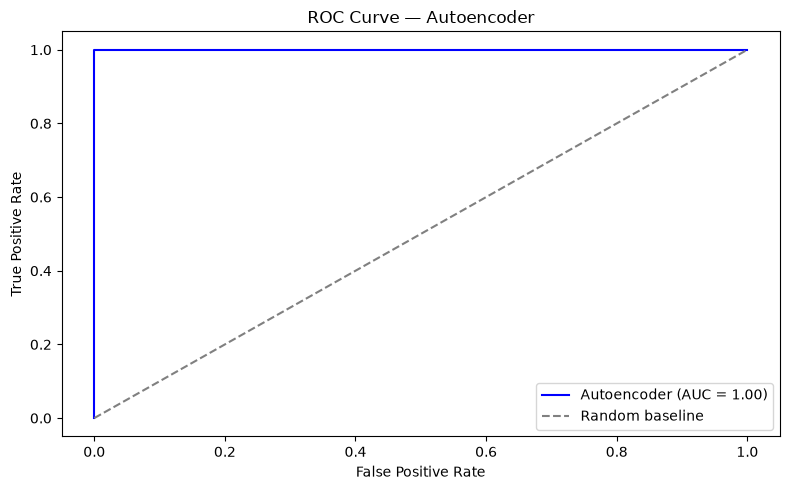

In [53]:
import os
os.makedirs('../../reports', exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, reconstruction_error)
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f'Autoencoder (AUC = {roc_auc_score(y_test, reconstruction_error):.2f})', color='blue')
plt.plot([0,1],[0,1],'--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Autoencoder')
plt.legend()
plt.tight_layout()
plt.savefig('../../reports/roc_autoencoder.png')
plt.show()

In [54]:
np.random.seed(42)
n_normal = 1000
n_anomaly = 50

normal = pd.DataFrame({
    'login_hour': np.random.randint(8, 18, n_normal),
    'after_hours_flag': np.zeros(n_normal),
    'session_duration_mins': np.random.normal(480, 60, n_normal),
    'files_accessed_count': np.random.randint(5, 50, n_normal),
    'bytes_transferred': np.random.normal(50000, 10000, n_normal),
    'usb_events_count': np.zeros(n_normal),
    'unique_domains_visited': np.random.randint(5, 30, n_normal),
    'email_count': np.random.randint(5, 40, n_normal),
    'email_ext_recipient_count': np.random.randint(0, 5, n_normal),
    'file_copy_to_removable': np.zeros(n_normal),
})

anomaly = pd.DataFrame({
    'login_hour': np.random.randint(0, 6, n_anomaly),
    'after_hours_flag': np.ones(n_anomaly),
    'session_duration_mins': np.random.normal(600, 30, n_anomaly),
    'files_accessed_count': np.random.randint(100, 500, n_anomaly),
    'bytes_transferred': np.random.normal(500000, 50000, n_anomaly),
    'usb_events_count': np.random.randint(3, 10, n_anomaly),
    'unique_domains_visited': np.random.randint(50, 100, n_anomaly),
    'email_count': np.random.randint(50, 200, n_anomaly),
    'email_ext_recipient_count': np.random.randint(10, 50, n_anomaly),
    'file_copy_to_removable': np.random.randint(5, 20, n_anomaly),
})

df = pd.concat([normal, anomaly], ignore_index=True)
y = np.array([0]*n_normal + [1]*n_anomaly)
X = df.values

print(f"Total samples: {len(X)}")
print(f"Normal: {sum(y==0)}, Threats: {sum(y==1)}")
print(f"Features: {df.columns.tolist()}")

Total samples: 1050
Normal: 1000, Threats: 50
Features: ['login_hour', 'after_hours_flag', 'session_duration_mins', 'files_accessed_count', 'bytes_transferred', 'usb_events_count', 'unique_domains_visited', 'email_count', 'email_ext_recipient_count', 'file_copy_to_removable']
